# VGG-style StandardCNN — Tiny ImageNet 200

Local project notebook. Dataset loading follows the supplied residual-CNN reference (`src.dataset.tiny_imagenet_dataset_2` and `BalancedClassSubset`). The model is imported separately from `model.py`.


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ---------------- EXPERIMENT CONFIGURATION ----------------
SEED = 42
NUM_CLASSES = 200
TRAIN_PER_CLASS = 450
VAL_PER_CLASS = 100
BATCH_SIZE = 64
NUM_WORKERS = 4
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 15
INITIAL_LR = 1e-3
MIN_LR = 1e-5

WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.1

SAVE_DIR = Path("checkpoints/vgg_standard_cnn")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("DataLoader workers:", NUM_WORKERS)

Device: mps
DataLoader workers: 4


## 1. Local model and reference dataset loader


In [2]:
# Run this notebook from your project root (where src/ and model.py are importable).
# If model.py is inside cnn_exp/, change the import to: from cnn_exp.model import StandardCNN
from archive.cnn.cnn_4_layer.model import StandardCNN
from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset_2 import (
    TinyImageNetLoader, show_image, get_tiny_imagenet_class_names,
    test_transform, means, stds, convert_to_rgb,
)

TINY_ROOT = Path('../../../../data/tiny_imagenet/tiny-imagenet-200-450train-100val')
SELECTED_CLASSES = list(range(NUM_CLASSES))
print('Dataset root:', TINY_ROOT)


Dataset root: ../data/tiny_imagenet/tiny-imagenet-200-450train-100val


In [3]:
# Same data pipeline and balanced split as the supplied residual-CNN notebook.
train_tf = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])
train_dataset, val_dataset, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=train_tf).load()
clean_train_dataset, _, _, _ = TinyImageNetLoader(seed=SEED, root=TINY_ROOT, train_transform=test_transform).load()
if not hasattr(clean_train_dataset, 'transform'):
    raise AttributeError('Expected the dataset to expose a transform attribute.')
clean_train_dataset.transform = test_transform
train_subset = BalancedClassSubset(train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED)
clean_train_subset = BalancedClassSubset(clean_train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED)
val_subset = BalancedClassSubset(val_dataset, SELECTED_CLASSES, VAL_PER_CLASS, seed=SEED + 1)
assert train_subset.samples == clean_train_subset.samples, 'Clean and augmented training subsets differ.'
assert len(train_subset) == NUM_CLASSES * TRAIN_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_PER_CLASS
FULL_CLASS_NAMES = get_tiny_imagenet_class_names(train_dataset, TINY_ROOT)
CLASS_NAMES = [FULL_CLASS_NAMES[i] for i in SELECTED_CLASSES]
print('Train:', len(train_subset), 'Validation:', len(val_subset))


Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Train: 90000 Validation: 20000


## 2. DataLoaders (macOS / Jupyter safe)

Set `NUM_WORKERS = 0` in the first configuration cell. This removes the notebook-local `seed_worker` multiprocessing problem. All three loaders use the same batch size; only the training loader shuffles.

In [4]:
# On macOS Jupyter, use NUM_WORKERS=0. Notebook-defined seed_worker
# cannot be imported by multiprocessing spawn workers.
# To use >0 workers later, move worker_init_fn to an importable .py module.
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": True,
    "prefetch_factor": 2,
}

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    generator=loader_generator,
    **loader_options,
)
val_loader = DataLoader(val_subset, shuffle=False, **loader_options)
clean_train_loader = DataLoader(clean_train_subset, shuffle=False, **loader_options)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1407
Validation batches: 313


## Visual Check

In [ ]:
NUM_SHOW = 10

train_images, train_labels = next(iter(train_loader))
val_images, val_labels_batch = next(iter(val_loader))

show_image(train_images, train_labels, NUM_SHOW, CLASS_NAMES, name="Train Images")
show_image(val_images, val_labels_batch, NUM_SHOW, CLASS_NAMES, name="Validation Images")

## 3. Model, optimizer and cosine scheduler

`model.py` contains the VGG-style architecture. AdamW starts at `1e-3`; cosine annealing reaches `1e-5` over 200 epochs. The scheduler steps **after every optimizer step**.

In [5]:
# Architecture lives in model.py, not in this notebook.
base_model = StandardCNN(
    num_classes=NUM_CLASSES,
    block3_dropout=0.10,
    block4_dropout=0.15,
    classifier_dropout=0.30,
)
print("Parameters:", sum(p.numel() for p in base_model.parameters()))

if DEVICE.type == "cuda" and torch.cuda.device_count() > 1:
    model = nn.DataParallel(base_model).to(DEVICE)
else:
    model = base_model.to(DEVICE)


def raw_model():
    return model.module if isinstance(model, nn.DataParallel) else model


criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=INITIAL_LR, weight_decay=WEIGHT_DECAY
)

# The scheduler advances once per training batch, not once per epoch.
TOTAL_STEPS = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_STEPS, eta_min=MIN_LR
)

Parameters: 4870024


## 4. Best and latest checkpoints

`best_model.pth` stores the best validation model. `latest_checkpoint.pth` stores the last completed epoch, optimizer, scheduler, history and RNG state. To resume, set `RESUME = True` below **before** running the training cell.

In [6]:
BEST_PATH = SAVE_DIR / 'best_model.pth'
LATEST_PATH = SAVE_DIR / 'latest_checkpoint.pth'
history = {k: [] for k in
           ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'clean_train_loss', 'clean_train_acc', 'lr',
            'generalization_gap']}
best_acc = -1.0
best_epoch = 0
stale_epochs = 0
start_epoch = 1


def rng_state():
    return dict(python=random.getstate(), numpy=np.random.get_state(), torch=torch.get_rng_state(),
                cuda=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
                loader=loader_generator.get_state())


def restore_rng(s):
    random.setstate(s['python'])
    np.random.set_state(s['numpy'])
    torch.set_rng_state(s['torch'])
    if torch.cuda.is_available() and s.get('cuda') is not None: torch.cuda.set_rng_state_all(s['cuda'])
    loader_generator.set_state(s['loader'])


def save_latest(epoch):
    payload = dict(epoch=epoch, model=raw_model().state_dict(), optimizer=optimizer.state_dict(),
                   scheduler=scheduler.state_dict(),
                   history=history, best_acc=best_acc, best_epoch=best_epoch, stale_epochs=stale_epochs,
                   rng=rng_state(),
                   config=dict(num_classes=NUM_CLASSES, batch_size=BATCH_SIZE, epochs=EPOCHS,
                               train_per_class=TRAIN_PER_CLASS, val_per_class=VAL_PER_CLASS))
    temp = LATEST_PATH.with_suffix('.tmp')
    torch.save(payload, temp)
    os.replace(temp, LATEST_PATH)


# Set RESUME=True only if latest_checkpoint.pth is available at LATEST_PATH.
RESUME = False
if RESUME:
    ck = torch.load(LATEST_PATH, map_location='cpu', weights_only=False)
    if ck['config']['batch_size'] != BATCH_SIZE or ck['config']['epochs'] != EPOCHS: raise ValueError(
        'Resume requires original batch size and epoch horizon.')
    raw_model().load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    # Restore optimizer state tensors to the active device.
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v): state[k] = v.to(DEVICE)
    history = ck['history']
    best_acc = ck['best_acc']
    best_epoch = ck['best_epoch']
    stale_epochs = ck['stale_epochs']
    start_epoch = ck['epoch'] + 1
    restore_rng(ck['rng'])
    print('Resuming from epoch', start_epoch, 'with LR', scheduler.get_last_lr()[0])


## 5. Training and validation

Run this cell to train. The latest checkpoint is saved after **every completed epoch**; interrupted epochs are repeated on resume. Training accuracy uses augmented images; validation uses clean images.

In [7]:
def run_epoch(loader, training=False):
    """
    Run one training or evaluation epoch.

    Optimizations:
    - Accumulate loss and accuracy on GPU.
    - Avoid CPU synchronization on every batch.
    - Transfer metrics to CPU only once per epoch.
    """

    if training:
        model.train()
    else:
        model.eval()

    # Keep metric accumulators on the same device.
    total_loss = torch.zeros((), device=DEVICE)
    total_correct = torch.zeros((), device=DEVICE)
    total = 0

    context = (
        torch.enable_grad()
        if training
        else torch.inference_mode()
    )

    with context:
        for images, labels in tqdm(
                loader,
                leave=False,
                desc="Train" if training else "Eval"
        ):
            # 1. Transfer batch to device
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # 2. Reset gradients
            if training:
                optimizer.zero_grad(set_to_none=True)

            # 3. Forward pass
            logits = model(images)
            loss = criterion(logits, labels)

            # 4. Backward pass and optimizer update
            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()

            # 5. Accumulate metrics on GPU
            batch_size = labels.size(0)
            total += batch_size
            total_loss += loss.detach() * batch_size
            total_correct += (
                    logits.detach().argmax(dim=1) == labels
            ).sum()

    # 6. Transfer metrics to CPU once per epoch
    avg_loss = (total_loss / total).item()
    accuracy = (total_correct * (100.0 / total)).item()

    return avg_loss, accuracy


In [8]:
# Resume starts from the checkpoint's next epoch; never reset the LR.
for epoch in tqdm(range(start_epoch, EPOCHS + 1)):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    clean_train_loss, clean_train_acc = run_epoch(clean_train_loader, training=False)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "clean_train_loss": clean_train_loss,
        "clean_train_acc": clean_train_acc,
        "lr": current_lr,
        "generalization_gap": train_acc - val_acc,
    }
    for name, value in epoch_metrics.items():
        history[name].append(value)

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch
        stale_epochs = 0
        torch.save(
            {
                "model": raw_model().state_dict(),
                "epoch": epoch,
                "val_acc": val_acc,
                "class_names": CLASS_NAMES,
            },
            BEST_PATH,
        )
    else:
        stale_epochs += 1

    # Always save the last completed epoch, including optimizer/scheduler/RNG.
    save_latest(epoch)
    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train: {train_acc:.2f}% / {train_loss:.4f} | "
        f"Val: {val_acc:.2f}% / {val_loss:.4f} | "
        f"Clean Train: {clean_train_acc:.2f}% / {clean_train_loss:.4f} | "
        f"LR: {current_lr:.7f} | "
        f"Best: {best_acc:.2f}% (epoch {best_epoch})"
    )

    if stale_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

  0%|          | 0/100 [00:00<?, ?it/s]

Train:   0%|          | 0/1407 [00:06<?, ?it/s]

Eval:   0%|          | 0/1407 [00:07<?, ?it/s]

Eval:   0%|          | 0/313 [00:06<?, ?it/s]

Epoch 001/100 | Train: 3.17% / 4.9531 | Val: 5.67% / 4.6660 | Clean Train: 5.64% / 4.6607 | LR: 0.0009998 | Best: 5.67% (epoch 1)


...

Eval:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 040/100 | Train: 51.57% / 2.6599 | Val: 52.92% / 2.5842 | Clean Train: 68.47% / 2.0580 | LR: 0.0006580 | Best: 52.92% (epoch 40)


Train:   0%|          | 0/1407 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. Curves and clean generalization gap

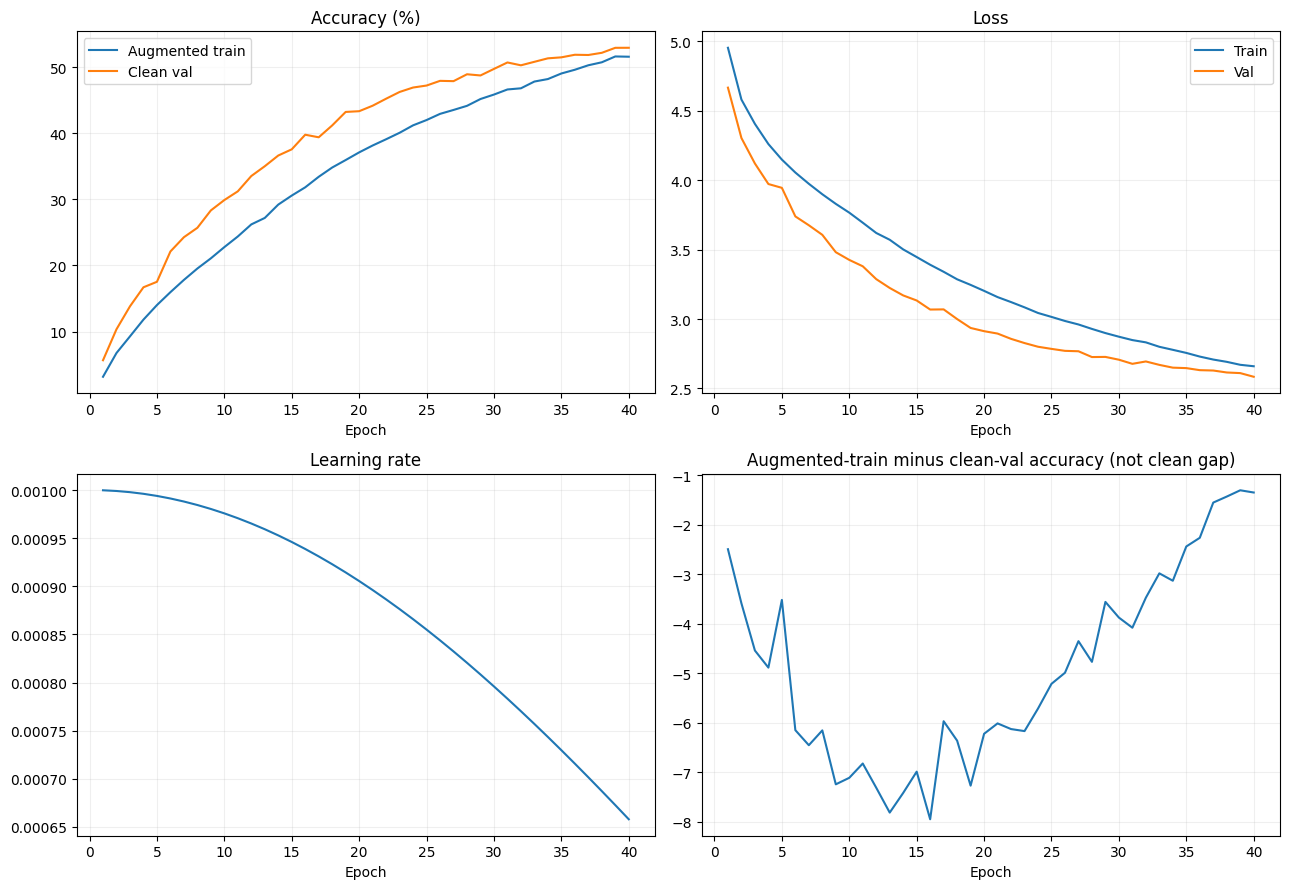

RuntimeError: DataLoader worker (pid(s) 40902, 40903, 40906, 40907) exited unexpectedly

In [9]:
h = pd.DataFrame(history)
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
axs[0, 0].plot(h.epoch, h.train_acc, label='Augmented train')
axs[0, 0].plot(h.epoch, h.val_acc, label='Clean val')
axs[0, 0].set_title('Accuracy (%)')
axs[0, 0].legend()
axs[0, 1].plot(h.epoch, h.train_loss, label='Train')
axs[0, 1].plot(h.epoch, h.val_loss, label='Val')
axs[0, 1].set_title('Loss')
axs[0, 1].legend()
axs[1, 0].plot(h.epoch, h.lr)
axs[1, 0].set_title('Learning rate')
axs[1, 1].plot(h.epoch, h.generalization_gap)
axs[1, 1].set_title('Augmented-train minus clean-val accuracy (not clean gap)')
for ax in axs.flat: ax.set_xlabel('Epoch');ax.grid(alpha=.2)
plt.tight_layout()
plt.show()
# Clean train/validation gap uses the best checkpoint and identical no-augmentation transforms.
best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
raw_model().load_state_dict(best['model'])
clean_train_loss, clean_train_acc = run_epoch(clean_train_loader)
clean_val_loss, clean_val_acc = run_epoch(val_loader)
print(
    f'Best checkpoint: clean train {clean_train_acc:.2f}%, clean val {clean_val_acc:.2f}%, gap {clean_train_acc - clean_val_acc:.2f} pp')


## 7. Extract full validation features and class separation

In [10]:
@torch.no_grad()
def extract_features(loader):
    model.eval()
    ff = []
    yy = []
    for x, y in tqdm(loader, desc='Features'):
        _, f = model(x.to(DEVICE), return_features=True)
        ff.append(f.cpu().numpy())
        yy.append(y.numpy())
    return np.concatenate(ff), np.concatenate(yy)


features, labels = extract_features(val_loader)
print('Feature shape:', features.shape)
# Exact mean intra-class Euclidean distance to class centroid; inter-class mean centroid distance.
centroids = np.stack([features[labels == i].mean(0) for i in range(NUM_CLASSES)])
intra = np.mean([np.linalg.norm(features[labels == i] - centroids[i], axis=1).mean() for i in range(NUM_CLASSES)])
from scipy.spatial.distance import pdist

inter = pdist(centroids).mean()
print(
    f'Mean intra-class distance to centroid: {intra:.4f} | Mean inter-class centroid distance: {inter:.4f} | Ratio: {inter / intra:.4f}')
np.savez_compressed(SAVE_DIR / 'validation_features.npz', features=features, labels=labels, centroids=centroids)


RuntimeError: DataLoader worker (pid(s) 40936, 40937, 40942, 40943) exited unexpectedly

## 8. Balanced fixed-seed 2D and interactive 3D t-SNE

In [ ]:
from sklearn.manifold import TSNE

rng = np.random.default_rng(SEED)
# 10 per class = 2,000 points, to avoid crowding; full features were used for separation above.
selected = np.concatenate(
    [rng.choice(np.flatnonzero(labels == i), size=min(10, (labels == i).sum()), replace=False) for i in
     range(NUM_CLASSES)])
vis_x = features[selected]
vis_y = labels[selected]
colors = plt.get_cmap('gist_ncar')(np.linspace(0, 1, NUM_CLASSES))
tsne2 = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto', perplexity=30).fit_transform(vis_x)
plt.figure(figsize=(12, 9))
for i in range(NUM_CLASSES):
    mask = vis_y == i
    plt.scatter(tsne2[mask, 0], tsne2[mask, 1], s=10, color=colors[i], alpha=.75)
plt.title('Fixed-seed class-balanced validation t-SNE (200 classes, 10/class)')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px

tsne3 = TSNE(n_components=3, random_state=SEED, init='pca', learning_rate='auto', perplexity=30).fit_transform(vis_x)
plot_df = pd.DataFrame(dict(x=tsne3[:, 0], y=tsne3[:, 1], z=tsne3[:, 2], class_name=[CLASS_NAMES[i] for i in vis_y]))
fig = px.scatter_3d(plot_df, x='x', y='y', z='z', color='class_name', opacity=.75,
                    title='Interactive 3D t-SNE — fixed seed')
fig.update_traces(marker=dict(size=3))
fig.update_layout(height=850, showlegend=False)
fig.show()
fig.write_html(str(SAVE_DIR / 'tsne_3d.html'))


### Reproducibility notes
- Exact mid-epoch resume is not supported; resume begins after the last completed saved epoch.
- Persistent multiworker prefetch and stochastic augmentation can prevent bit-for-bit identical resumed runs, even with restored RNG state.
- Verify train/validation image-content disjointness before interpreting validation accuracy.
- No CutMix is used here. This is a clean-label cross-entropy baseline with mild augmentation.
- The 70% clean-validation accuracy is a target, not a guarantee.